## Modeling
AI Productivity: When AI Enters the Workflow
Research question: Beyond which threshold of AI usage does rework erode operational margins?
 
Three objectives:
  1. Find the exact AI threshold within hourly pricing
  2. Multivariate controls + feature importance
  3. Counterfactual: what if we migrate hourly → fixed pricing?

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                             mean_squared_error, r2_score)
from sklearn.inspection import permutation_importance
from scipy import stats
from scipy.stats import spearmanr
import shap
 
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")


In [22]:
df = pd.read_csv('ai_productivity_clean.csv')
df.head()

,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,profit_margin,efficiency_ratio,rework_ratio,cost_per_hour,revenue_per_hour,total_effort,profit_per_hour,delivery_days_actual,delivery_speed,ai_usage_bin
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,0.305033,0.673657,0.275229,45.369594,65.283093,9.73,15.615622,5,0.500000,high
1,T00001,Client_H,P028,low,Media,release,junior,1,2.0,medium,...,0.594834,0.863445,0.470588,36.048319,88.971639,14.00,35.987857,2,0.285714,low
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,0.734351,0.727811,0.320710,43.197633,162.611834,11.16,90.416667,7,1.400000,low_medium
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,0.363321,0.854321,0.000000,53.429630,83.919224,28.35,30.489594,3,1.000000,low
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,0.527755,0.748735,0.141653,56.537943,119.721754,6.77,55.344165,4,0.571429,low_medium



# 7.0  PREPROCESSING FOR MODELING
At this point, the dataset is fully cleaned + feature-engineered from sections 4 and 5. We now prepare it for ML.
 
## 7.0.1  Select columns to use 

In [18]:
DROP_COLS = [
    'task_id', 'project_id', 'client', 'created_by',  
    'jira_ticket',                                       
    'created_at', 'delivered_at', 'updated_at',          
    'ai_assisted',       
    'ai_usage_bin',       
    'task_status',        
    'workflow_stage',   
    'legacy_ai_flag',     
    'content_version',   
    'profit',            
    'revenue',            
    'cost',               
    'billable_hours',     
]

In [19]:
drop_cols = [c for c in DROP_COLS if c in df.columns]
df_model = df.drop(columns=drop_cols).copy()
 
print("Columns kept for modeling:")
print(list(df_model.columns))
print(f"\nShape: {df_model.shape}")

Columns kept for modeling:
['client_tier', 'team', 'task_type', 'seniority', 'task_complexity_score', 'brief_quality_score', 'deadline_pressure', 'scope_change_flag', 'pricing_model', 'sla_days', 'sla_breach', 'hours_spent', 'ai_usage_pct', 'revisions', 'errors', 'rework_hours', 'outcome_score', 'actual_days', 'margin', 'efficiency_ratio', 'rework_ratio']

Shape: (3193, 21)


## 7.0.2  Target variables 

In [23]:
df['is_loss'] = (df['profit_margin'] < 0).astype(int)
 
print(f"\nLoss rate: {df['is_loss'].mean()*100:.1f}%")
print(f"Missing in profit_margin: {df['profit_margin'].isna().sum()}")


Loss rate: 25.1%
Missing in profit_margin: 0


## 7.0.3  Drop rows with missing targets

In [25]:
df = df.dropna(subset=['profit_margin', 'ai_usage_pct'])
print(f"\nRows after dropping missing targets: {len(df)}")


Rows after dropping missing targets: 3193


## 7.0.4  Categorical encoding

In [26]:
CAT_COLS = df.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns to encode: {CAT_COLS}")
 

df_encoded = pd.get_dummies(df, columns=CAT_COLS, drop_first=True)
print(f"Shape after one-hot encoding: {df_encoded.shape}")
 
# For models that need label encoding 
df_label = df.copy()
le = LabelEncoder()
for col in CAT_COLS:
    df_label[col] = le.fit_transform(df_label[col].astype(str))
 


Categorical columns to encode: ['task_id', 'client', 'project_id', 'client_tier', 'team', 'task_type', 'seniority', 'deadline_pressure', 'pricing_model', 'created_at', 'delivered_at', 'created_by', 'updated_at', 'task_status', 'workflow_stage', 'jira_ticket', 'legacy_ai_flag', 'content_version', 'ai_usage_bin']
Shape after one-hot encoding: (3193, 7284)


C:\Users\jules\AppData\Local\Temp\ipykernel_10236\1052459733.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  CAT_COLS = df.select_dtypes(include='object').columns.tolist()


## 7.0.5  Handle remaining missing values in features

In [29]:
num_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
missing_before = df_encoded[num_cols].isna().sum()
missing_cols = missing_before[missing_before > 0]

if len(missing_cols) > 0:
    print(f"\nImputing missing values in: {missing_cols.index.tolist()}")
    for col in missing_cols.index:
        df_encoded[col].fillna(df_encoded[col].median(), inplace=True)
        df_label[col].fillna(df_label[col].median(), inplace=True)
 
print(f"Missing values after imputation: {df_encoded.isna().sum().sum()}")
 

Missing values after imputation: 0


## 7.0.6  Feature / target split

In [30]:
TARGET_REG  = 'profit_margin'       
TARGET_CLS  = 'is_loss'             
 
NON_FEATURES = ['profit_margin', 'profit_per_hour', 'is_loss']
feature_cols = [c for c in df_encoded.columns if c not in NON_FEATURES]
 
X = df_encoded[feature_cols]
y_reg = df_encoded[TARGET_REG]
y_cls = df_encoded[TARGET_CLS]
 
print(f"\nFeature matrix shape: {X.shape}")
print(f"Regression target (profit_margin) — mean: {y_reg.mean():.3f}, std: {y_reg.std():.3f}")
print(f"Classification target (is_loss) — positive rate: {y_cls.mean():.2%}")


Feature matrix shape: (3193, 7281)
Regression target (profit_margin) — mean: 0.148, std: 0.768
Classification target (is_loss) — positive rate: 25.12%


## 7.0.7  Scale numerical features (for logistic regression)

In [31]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 7.1  OBJECTIVE 1 — Find the exact AI threshold within hourly pricing

## 7.1.1  Segmented / piecewise regression 


Hourly subset: 1541 tasks

Best breakpoint (highest R²): ai_usage_pct = 0.30 (30%)
R² at best breakpoint: 0.0093


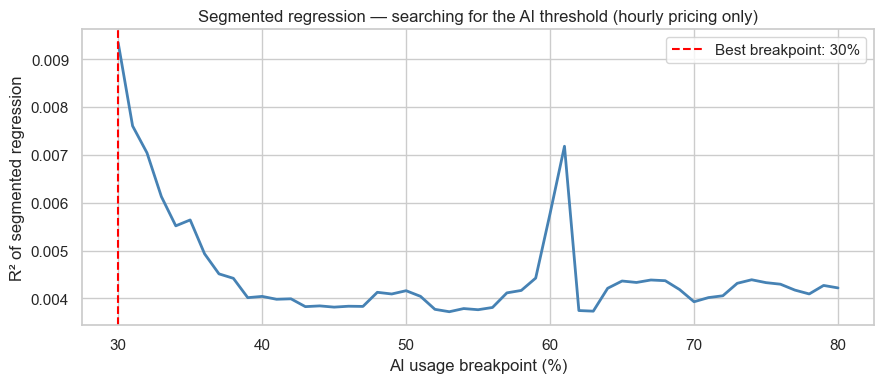


Segmented regression coefficients at breakpoint 0.30:
  Intercept:       0.0326
  ai_usage_pct:    -0.7206  (slope BELOW threshold)
  above_threshold: 0.0340  (level shift at threshold)
  ai_above:        0.7174  (slope CHANGE above threshold)

Interpretation:
  Below 30%: each 1pp increase in AI usage → -72.059pp margin change
  Above 30%: each 1pp increase in AI usage → -0.322pp margin change


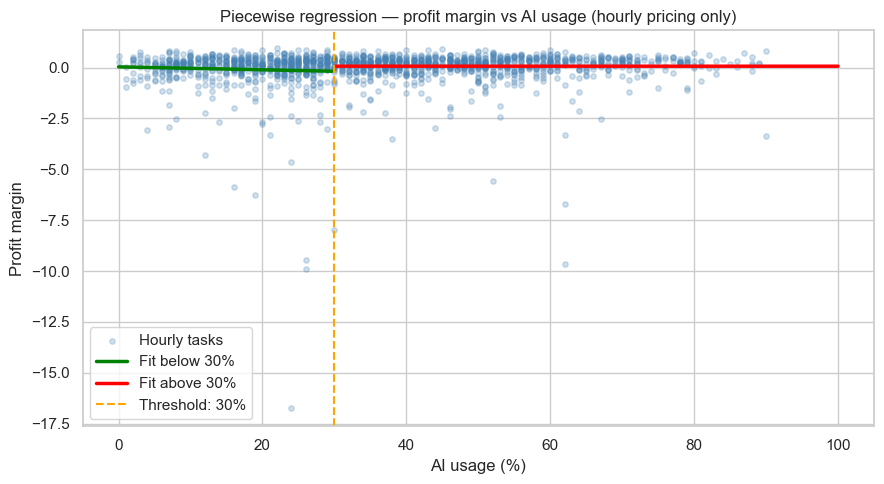

In [33]:
df_hourly = df[df['pricing_model'] == 'hourly'].dropna(
    subset=['ai_usage_pct', 'profit_margin']
).copy()
 
print(f"\nHourly subset: {len(df_hourly)} tasks")
 
breakpoints = np.arange(0.30, 0.81, 0.01)
r2_scores = []
 
for bp in breakpoints:
    df_hourly['above'] = (df_hourly['ai_usage_pct'] > bp).astype(int)
    df_hourly['ai_above'] = df_hourly['ai_usage_pct'] * df_hourly['above']  # interaction term
 
    X_bp = df_hourly[['ai_usage_pct', 'above', 'ai_above']]
    y_bp = df_hourly['profit_margin']
 
    model_bp = LinearRegression().fit(X_bp, y_bp)
    r2_scores.append(r2_score(y_bp, model_bp.predict(X_bp)))
 
best_bp = breakpoints[np.argmax(r2_scores)]
print(f"\nBest breakpoint (highest R²): ai_usage_pct = {best_bp:.2f} ({best_bp*100:.0f}%)")
print(f"R² at best breakpoint: {max(r2_scores):.4f}")
 

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(breakpoints * 100, r2_scores, color='steelblue', linewidth=2)
ax.axvline(best_bp * 100, color='red', linestyle='--', linewidth=1.5,
           label=f'Best breakpoint: {best_bp*100:.0f}%')
ax.set_xlabel('AI usage breakpoint (%)')
ax.set_ylabel('R² of segmented regression')
ax.set_title('Segmented regression — searching for the AI threshold (hourly pricing only)')
ax.legend()
plt.tight_layout()
plt.savefig('obj1_breakpoint_search.png', dpi=120)
plt.show()

df_hourly['above'] = (df_hourly['ai_usage_pct'] > best_bp).astype(int)
df_hourly['ai_above'] = df_hourly['ai_usage_pct'] * df_hourly['above']
 
X_final = df_hourly[['ai_usage_pct', 'above', 'ai_above']]
y_final = df_hourly['profit_margin']
 
seg_model = LinearRegression().fit(X_final, y_final)
 
print(f"\nSegmented regression coefficients at breakpoint {best_bp:.2f}:")
print(f"  Intercept:       {seg_model.intercept_:.4f}")
print(f"  ai_usage_pct:    {seg_model.coef_[0]:.4f}  (slope BELOW threshold)")
print(f"  above_threshold: {seg_model.coef_[1]:.4f}  (level shift at threshold)")
print(f"  ai_above:        {seg_model.coef_[2]:.4f}  (slope CHANGE above threshold)")
print(f"\nInterpretation:")
print(f"  Below {best_bp*100:.0f}%: each 1pp increase in AI usage → {seg_model.coef_[0]*100:.3f}pp margin change")
slope_above = seg_model.coef_[0] + seg_model.coef_[2]
print(f"  Above {best_bp*100:.0f}%: each 1pp increase in AI usage → {slope_above*100:.3f}pp margin change")
 
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df_hourly['ai_usage_pct'] * 100, df_hourly['profit_margin'],
           alpha=0.25, s=15, color='steelblue', label='Hourly tasks')
 
x_range = np.linspace(0, 1, 200)
below = x_range[x_range <= best_bp]
above = x_range[x_range > best_bp]
 
def predict_pw(x, model, bp):
    ab = (x > bp).astype(int)
    return model.predict(np.column_stack([x, ab, x * ab]))
 
ax.plot(below * 100, predict_pw(below, seg_model, best_bp), color='green',
        linewidth=2.5, label=f'Fit below {best_bp*100:.0f}%')
ax.plot(above * 100, predict_pw(above, seg_model, best_bp), color='red',
        linewidth=2.5, label=f'Fit above {best_bp*100:.0f}%')
ax.axvline(best_bp * 100, color='orange', linestyle='--', linewidth=1.5,
           label=f'Threshold: {best_bp*100:.0f}%')
ax.set_xlabel('AI usage (%)')
ax.set_ylabel('Profit margin')
ax.set_title('Piecewise regression — profit margin vs AI usage (hourly pricing only)')
ax.legend()
plt.tight_layout()
plt.savefig('obj1_piecewise_fit.png', dpi=120)
plt.show()

## 7.1.2  Bootstrap confidence interval on the threshold

Threshold: 30%  |  95% Bootstrap CI: [30%, 80%]


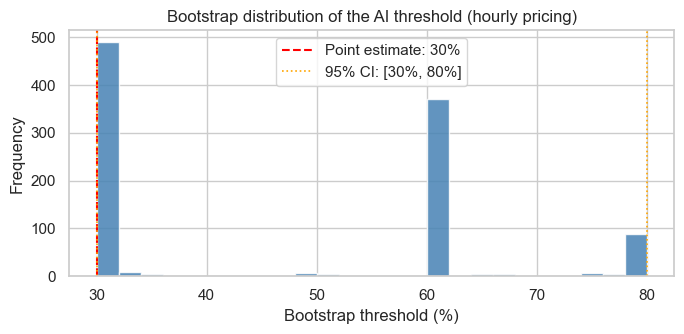

In [34]:
n_boot = 1000
boot_thresholds = []
 
for _ in range(n_boot):
    sample = df_hourly.sample(frac=1, replace=True, random_state=None)
    r2_boot = []
    for bp in breakpoints:
        sample['above'] = (sample['ai_usage_pct'] > bp).astype(int)
        sample['ai_above'] = sample['ai_usage_pct'] * sample['above']
        X_b = sample[['ai_usage_pct', 'above', 'ai_above']]
        m = LinearRegression().fit(X_b, sample['profit_margin'])
        r2_boot.append(r2_score(sample['profit_margin'], m.predict(X_b)))
    boot_thresholds.append(breakpoints[np.argmax(r2_boot)])
 
ci_low = np.percentile(boot_thresholds, 2.5)
ci_high = np.percentile(boot_thresholds, 97.5)
print(f"Threshold: {best_bp*100:.0f}%  |  95% Bootstrap CI: [{ci_low*100:.0f}%, {ci_high*100:.0f}%]")
 
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(np.array(boot_thresholds) * 100, bins=25, color='steelblue',
        edgecolor='white', alpha=0.85)
ax.axvline(best_bp * 100, color='red', linestyle='--', linewidth=1.5,
           label=f'Point estimate: {best_bp*100:.0f}%')
ax.axvline(ci_low * 100, color='orange', linestyle=':', linewidth=1.2,
           label=f'95% CI: [{ci_low*100:.0f}%, {ci_high*100:.0f}%]')
ax.axvline(ci_high * 100, color='orange', linestyle=':', linewidth=1.2)
ax.set_xlabel('Bootstrap threshold (%)')
ax.set_ylabel('Frequency')
ax.set_title('Bootstrap distribution of the AI threshold (hourly pricing)')
ax.legend()
plt.tight_layout()
plt.savefig('obj1_bootstrap_ci.png', dpi=120)
plt.show()
 

# 7.2  OBJECTIVE 2 — Multivariate controls + feature importance

In [36]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=SEED
)
_, _, y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.2, random_state=SEED, stratify=y_cls
)
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## 7.2.1  Logistic regression — binary loss prediction

              precision    recall  f1-score   support

  Profitable       0.75      0.99      0.85       478
        Loss       0.20      0.01      0.01       161

    accuracy                           0.74       639
   macro avg       0.47      0.50      0.43       639
weighted avg       0.61      0.74      0.64       639

AUC-ROC: 0.521
5-fold CV AUC: 0.518 ± 0.026


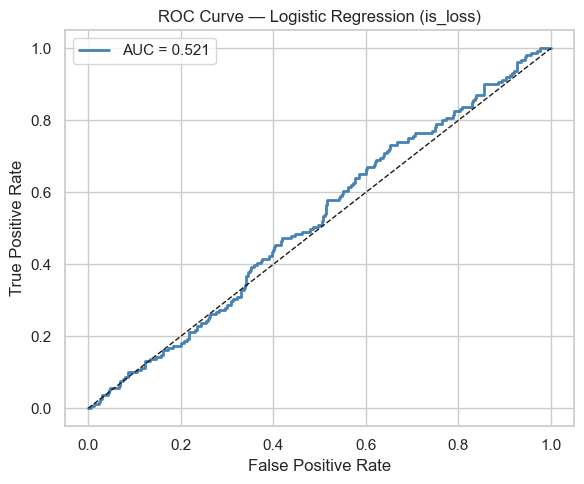


Top 15 features by absolute coefficient (logistic regression):
       feature  coefficient
task_id_T00834     0.191662
task_id_T01498     0.187934
task_id_T00808     0.179734
task_id_T01422     0.177748
task_id_T01183     0.177416
task_id_T00273     0.176454
task_id_T02058     0.175862
task_id_T01089     0.175749
task_id_T00460     0.173886
task_id_T01537     0.172318
task_id_T00622     0.172279
task_id_T01548     0.169674
task_id_T00304     0.169530
task_id_T00717     0.169043
task_id_T02451     0.166520


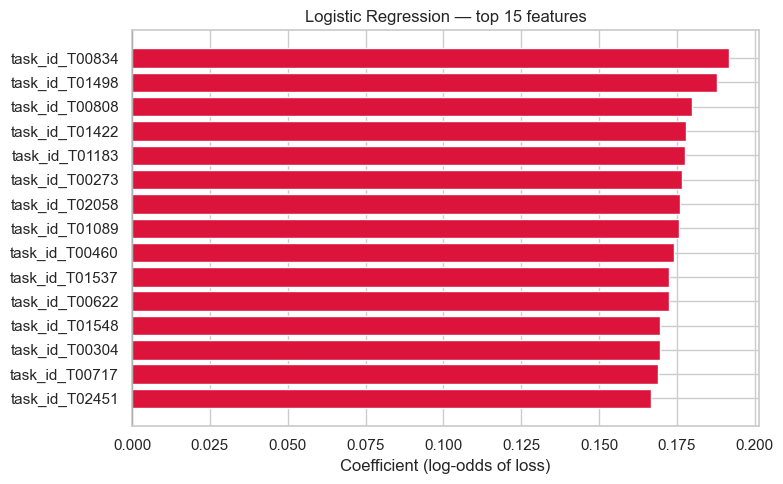

In [37]:
log_reg = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
log_reg.fit(X_train_sc, y_train_cls)
 
y_pred_cls = log_reg.predict(X_test_sc)
y_prob_cls = log_reg.predict_proba(X_test_sc)[:, 1]
 
print(classification_report(y_test_cls, y_pred_cls, target_names=['Profitable', 'Loss']))
print(f"AUC-ROC: {roc_auc_score(y_test_cls, y_prob_cls):.3f}")
 
cv_auc = cross_val_score(log_reg, X_train_sc, y_train_cls,
                         cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                         scoring='roc_auc')
print(f"5-fold CV AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
 
fpr, tpr, _ = roc_curve(y_test_cls, y_prob_cls)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'AUC = {roc_auc_score(y_test_cls, y_prob_cls):.3f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression (is_loss)')
ax.legend()
plt.tight_layout()
plt.savefig('obj2_roc_logistic.png', dpi=120)
plt.show()

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(15)
 
print("\nTop 15 features by absolute coefficient (logistic regression):")
print(coef_df.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds of loss)')
ax.set_title('Logistic Regression — top 15 features')
plt.tight_layout()
plt.savefig('obj2_logistic_coefs.png', dpi=120)
plt.show()
 

## 7.2.2  OLS regression — predict profit_margin with interaction term

In [38]:
X_ols = X.copy()
 
pricing_hourly_col = [c for c in X_ols.columns if 'pricing_model' in c and 'hourly' in c]
if pricing_hourly_col:
    X_ols['ai_x_hourly'] = X_ols['ai_usage_pct'] * X_ols[pricing_hourly_col[0]]
    print(f"Interaction term created: ai_usage_pct × {pricing_hourly_col[0]}")
 
ols = LinearRegression()
ols.fit(X_ols, y_reg)
y_pred_ols = ols.predict(X_ols)
 
print(f"OLS R² (in-sample): {r2_score(y_reg, y_pred_ols):.3f}")
 
cv_r2 = cross_val_score(ols, X_ols, y_reg, cv=5, scoring='r2')
print(f"5-fold CV R²: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
 

ols_coef_df = pd.DataFrame({
    'feature': X_ols.columns,
    'coefficient': ols.coef_
}).sort_values('coefficient', key=abs, ascending=False).head(15)
print("\nTop 15 OLS coefficients:")
print(ols_coef_df.to_string(index=False))
 

Interaction term created: ai_usage_pct × pricing_model_hourly
OLS R² (in-sample): 1.000
5-fold CV R²: 0.221 ± 0.155

Top 15 OLS coefficients:
               feature  coefficient
        task_id_T00559    -6.062248
jira_ticket_JIRA-21794    -6.062248
        task_id_T00422    -3.545704
        task_id_T01002    -2.904428
jira_ticket_JIRA-80666    -2.904428
        task_id_T02111     2.819135
jira_ticket_JIRA-35681    -2.724280
        task_id_T02821    -2.724280
        task_id_T02909    -2.232521
jira_ticket_JIRA-85335    -2.232521
        task_id_T01353    -1.918279
jira_ticket_JIRA-96190    -1.852239
        task_id_T01980    -1.852239
        task_id_T01863     1.793271
        task_id_T02827    -1.636382


## 7.2.3  Random Forest — non-linear importance

RF R² (test): 0.591
RF RMSE (test): 0.6669
5-fold CV R²: 0.806 ± 0.110

Top 15 features (RF MDI importance):
                 feature  importance
                  profit    0.703403
        revenue_per_hour    0.136857
           cost_per_hour    0.121203
                 revenue    0.020783
                    cost    0.012253
             hours_spent    0.002354
            total_effort    0.000717
          billable_hours    0.000691
          delivery_speed    0.000470
        efficiency_ratio    0.000403
            rework_ratio    0.000265
deadline_pressure_medium    0.000208
     legacy_ai_flag_true    0.000105
        seniority_senior    0.000081
           outcome_score    0.000048


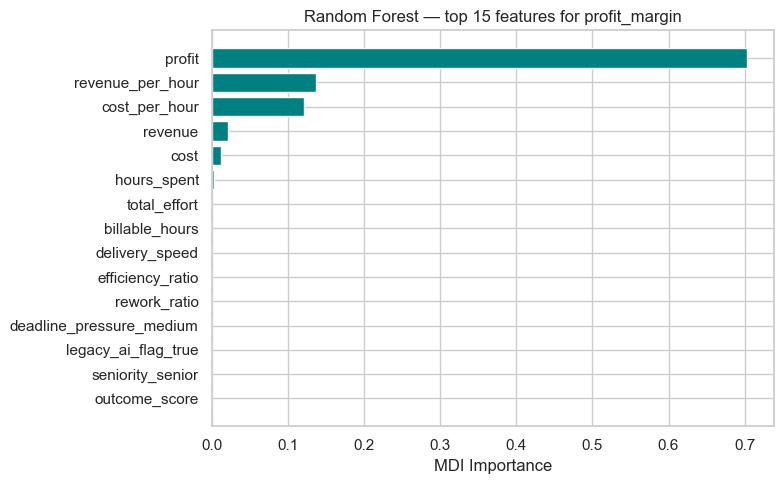

In [39]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train_reg)
y_pred_rf = rf.predict(X_test)
 
print(f"RF R² (test): {r2_score(y_test_reg, y_pred_rf):.3f}")
print(f"RF RMSE (test): {np.sqrt(mean_squared_error(y_test_reg, y_pred_rf)):.4f}")
 
cv_rf = cross_val_score(rf, X, y_reg, cv=5, scoring='r2', n_jobs=-1)
print(f"5-fold CV R²: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")
 
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)
 
print("\nTop 15 features (RF MDI importance):")
print(feat_imp.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1], color='teal')
ax.set_xlabel('MDI Importance')
ax.set_title('Random Forest — top 15 features for profit_margin')
plt.tight_layout()
plt.savefig('obj2_rf_importance.png', dpi=120)
plt.show()

## 7.2.4  SHAP values — explain the RF

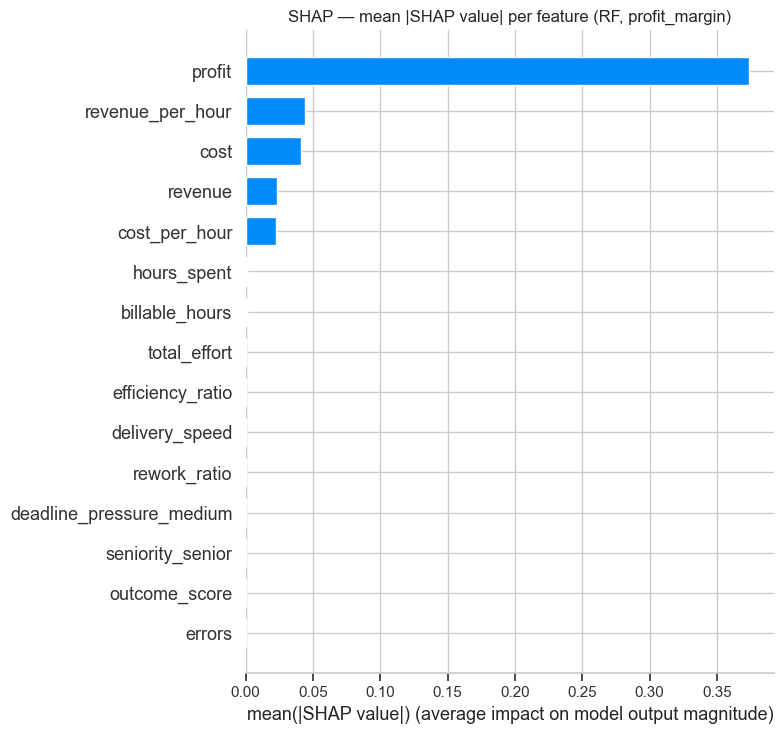

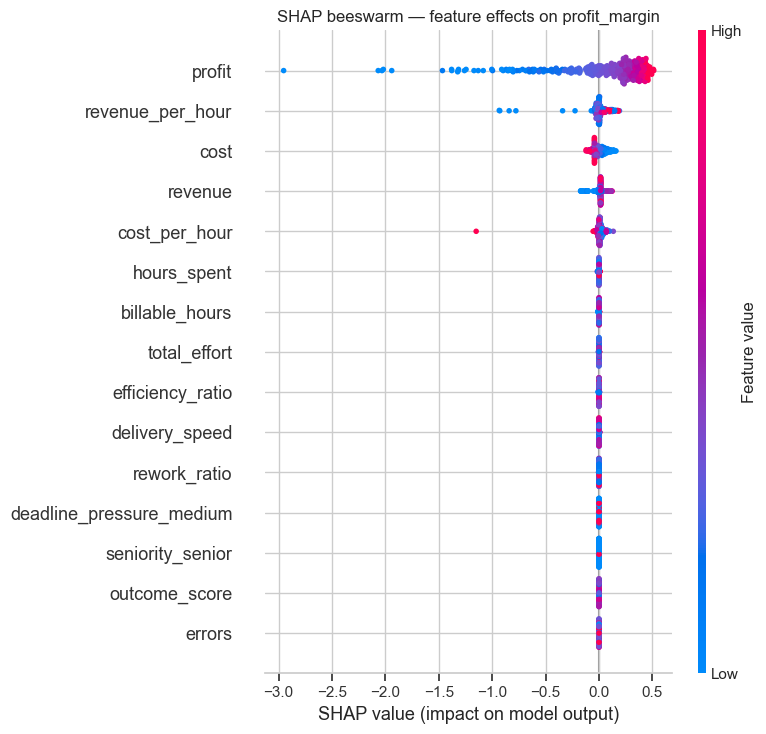

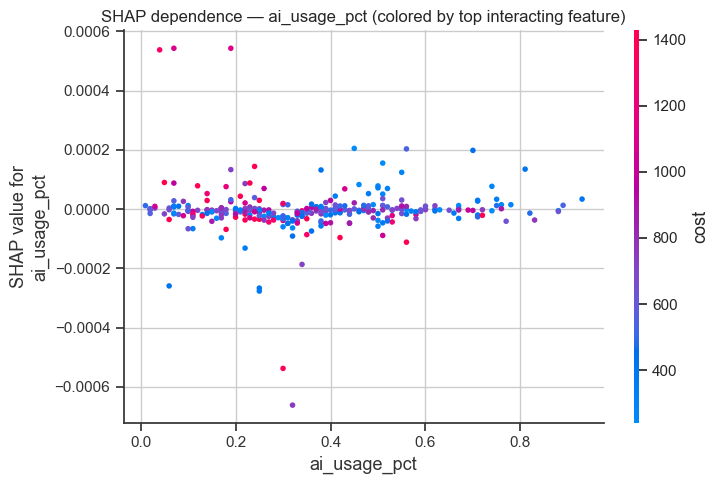

In [40]:
shap_sample = X_test.sample(min(300, len(X_test)), random_state=SEED)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(shap_sample)
 
shap.summary_plot(shap_values, shap_sample, plot_type='bar',
                  max_display=15, show=False)
plt.title('SHAP — mean |SHAP value| per feature (RF, profit_margin)')
plt.tight_layout()
plt.savefig('obj2_shap_bar.png', dpi=120)
plt.show()
 
shap.summary_plot(shap_values, shap_sample, max_display=15, show=False)
plt.title('SHAP beeswarm — feature effects on profit_margin')
plt.tight_layout()
plt.savefig('obj2_shap_beeswarm.png', dpi=120)
plt.show()
 
shap.dependence_plot('ai_usage_pct', shap_values, shap_sample,
                     interaction_index='auto', show=False)
plt.title('SHAP dependence — ai_usage_pct (colored by top interacting feature)')
plt.tight_layout()
plt.savefig('obj2_shap_dependence_ai.png', dpi=120)
plt.show()
 

# 7.3  OBJECTIVE 3 — Counterfactual: migrate hourly → fixed pricing

## 7.3.1  Propensity Score Matching


In [44]:

df_match = df_model[df_model['pricing_model'].isin(['hourly', 'fixed'])].copy()
df_match['treated'] = (df_match['pricing_model'] == 'hourly').astype(int)
 
print(f"\nMatching pool: {len(df_match)} tasks")
print(f"  Hourly (treated): {df_match['treated'].sum()}")
print(f"  Fixed (control):  {(df_match['treated'] == 0).sum()}")

COVARIATE_COLS = ['task_type', 'seniority', 'client_tier', 'team',
                  'task_complexity_score', 'brief_quality_score',
                  'ai_usage_pct', 'hours_spent', 'revisions', 'errors']
 

df_match_enc = df_match[COVARIATE_COLS + ['treated', 'profit_margin', 'is_loss']].copy()
for col in df_match_enc.select_dtypes('object').columns:
    df_match_enc[col] = LabelEncoder().fit_transform(df_match_enc[col].astype(str))
df_match_enc = df_match_enc.dropna()
 
X_psm = df_match_enc[COVARIATE_COLS]
T_psm = df_match_enc['treated']
 

ps_model = LogisticRegression(max_iter=1000, random_state=SEED)
ps_model.fit(StandardScaler().fit_transform(X_psm), T_psm)
df_match_enc['propensity_score'] = ps_model.predict_proba(
    StandardScaler().fit_transform(X_psm)
)[:, 1]
 
print(f"\nPropensity score distribution:")
print(df_match_enc.groupby('treated')['propensity_score'].describe().round(3))
 

CALIPER = 0.05
treated_df  = df_match_enc[df_match_enc['treated'] == 1].copy()
control_df  = df_match_enc[df_match_enc['treated'] == 0].copy()
 
matched_treated_idx  = []
matched_control_idx  = []
used_control_idx     = set()
 
for t_idx, t_row in treated_df.iterrows():
    ps_diffs = (control_df['propensity_score'] - t_row['propensity_score']).abs()
    ps_diffs = ps_diffs[~ps_diffs.index.isin(used_control_idx)]
    if len(ps_diffs) == 0:
        continue
    best_match = ps_diffs.idxmin()
    if ps_diffs[best_match] <= CALIPER:
        matched_treated_idx.append(t_idx)
        matched_control_idx.append(best_match)
        used_control_idx.add(best_match)
 
matched = pd.concat([
    df_match_enc.loc[matched_treated_idx].assign(group='hourly'),
    df_match_enc.loc[matched_control_idx].assign(group='fixed')
])
 
print(f"\nMatched pairs: {len(matched_treated_idx)}")
print(f"  Hourly (treated): {len(matched_treated_idx)}")
print(f"  Fixed  (control): {len(matched_control_idx)}")
 
# ATT: Average Treatment Effect on the Treated
hourly_margin = matched[matched['group'] == 'hourly']['profit_margin']
fixed_margin  = matched[matched['group'] == 'fixed']['profit_margin']
 
att_margin = hourly_margin.mean() - fixed_margin.mean()
print(f"\nATT (Average Treatment Effect on the Treated):")
print(f"  Mean profit_margin — Hourly: {hourly_margin.mean():.4f}")
print(f"  Mean profit_margin — Fixed:  {fixed_margin.mean():.4f}")
print(f"  Estimated margin GAIN if switched to fixed: {-att_margin:.4f}  ({-att_margin*100:.2f}pp)")
 
# T-test for significance
t_stat, p_val = stats.ttest_rel(fixed_margin.values, hourly_margin.values)
print(f"  Paired t-test: t={t_stat:.3f}, p={p_val:.4f}")
print(f"  {'Statistically significant (p < 0.05)' if p_val < 0.05 else 'Not significant at 0.05 level'}")
 
# Loss rate comparison
hourly_loss = matched[matched['group'] == 'hourly']['is_loss'].mean()
fixed_loss  = matched[matched['group'] == 'fixed']['is_loss'].mean()
print(f"\n  Loss rate — Hourly: {hourly_loss:.1%}")
print(f"  Loss rate — Fixed:  {fixed_loss:.1%}")
print(f"  Estimated loss-rate REDUCTION: {(hourly_loss - fixed_loss)*100:.1f}pp")
 


Matching pool: 2741 tasks
  Hourly (treated): 1541
  Fixed (control):  1200


KeyError: "['profit_margin', 'is_loss'] not in index"

## 7.3.2  Bootstrap CI on the ATT

In [42]:
boot_atts = []
for _ in range(1000):
    idx = np.random.choice(len(matched_treated_idx), len(matched_treated_idx), replace=True)
    t_boot = np.array([hourly_margin.values[i] for i in idx])
    c_boot = np.array([fixed_margin.values[i] for i in idx])
    boot_atts.append(c_boot.mean() - t_boot.mean())  # gain = fixed - hourly
 
att_ci_low  = np.percentile(boot_atts, 2.5)
att_ci_high = np.percentile(boot_atts, 97.5)
print(f"Estimated margin gain: {np.mean(boot_atts):.4f}")
print(f"95% Bootstrap CI: [{att_ci_low:.4f}, {att_ci_high:.4f}]")
print(f"  = [{att_ci_low*100:.2f}pp, {att_ci_high*100:.2f}pp]")

NameError: name 'matched_treated_idx' is not defined

## 7.3.3  Visualize: before/after matching covariate balance

NameError: name 'df_match_enc' is not defined

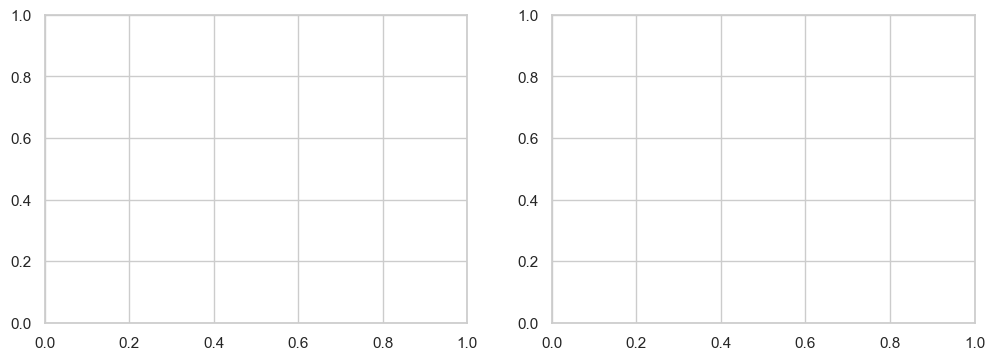

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Unmatched propensity score overlap
unmatched_h = df_match_enc[df_match_enc['treated'] == 1]['propensity_score']
unmatched_f = df_match_enc[df_match_enc['treated'] == 0]['propensity_score']
axes[0].hist(unmatched_h, bins=30, alpha=0.6, color='crimson', label='Hourly (before)')
axes[0].hist(unmatched_f, bins=30, alpha=0.6, color='steelblue', label='Fixed (before)')
axes[0].set_title('Propensity score overlap — before matching')
axes[0].legend()
 
# Matched propensity score overlap
matched_h_ps = matched[matched['group'] == 'hourly']['propensity_score']
matched_f_ps = matched[matched['group'] == 'fixed']['propensity_score']
axes[1].hist(matched_h_ps, bins=30, alpha=0.6, color='crimson', label='Hourly (matched)')
axes[1].hist(matched_f_ps, bins=30, alpha=0.6, color='steelblue', label='Fixed (matched)')
axes[1].set_title('Propensity score overlap — after matching')
axes[1].legend()
 
plt.suptitle('Propensity score matching — covariate balance check', fontsize=12)
plt.tight_layout()
plt.savefig('obj3_psm_balance.png', dpi=120)
plt.show()
 
# Outcome comparison plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
for ax, target, label in zip(
    axes,
    ['profit_margin', 'is_loss'],
    ['Profit margin', 'Loss rate (%)']
):
    vals_h = matched[matched['group'] == 'hourly'][target]
    vals_f = matched[matched['group'] == 'fixed'][target]
    if target == 'is_loss':
        ax.bar(['Hourly', 'Fixed'], [vals_h.mean()*100, vals_f.mean()*100],
               color=['crimson', 'steelblue'])
        ax.set_ylabel('%')
    else:
        ax.boxplot([vals_h, vals_f], labels=['Hourly', 'Fixed'],
                   patch_artist=True,
                   boxprops=dict(facecolor='lightblue'))
        ax.set_ylabel('Profit margin')
    ax.set_title(f'{label} — matched sample (hourly vs fixed)')
 
plt.suptitle('Counterfactual outcomes after propensity score matching', fontsize=12)
plt.tight_layout()
plt.savefig('obj3_counterfactual_outcomes.png', dpi=120)
plt.show()

# 7.4  SUMMARY TABLE — Key numbers for Section 9 (Business Decision)

In [35]:
print("\n" + "="*70)
print("MODELING SUMMARY — inputs for Section 9 Business Decision")
print("="*70)
 
summary = {
    'AI threshold (hourly, point estimate)': f"{best_bp*100:.0f}%",
    'AI threshold (95% Bootstrap CI)':       f"[{ci_low*100:.0f}%, {ci_high*100:.0f}%]",
    'Logistic Regression AUC (5-fold CV)':   f"{cv_auc.mean():.3f} ± {cv_auc.std():.3f}",
    'Random Forest R² (5-fold CV)':          f"{cv_rf.mean():.3f} ± {cv_rf.std():.3f}",
    'Top driver (SHAP / RF MDI)':            feat_imp.iloc[0]['feature'],
    'Matched pairs (PSM)':                   len(matched_treated_idx),
    'Estimated margin gain (hourly→fixed)':  f"{np.mean(boot_atts)*100:.2f}pp",
    'Margin gain 95% CI':                    f"[{att_ci_low*100:.2f}pp, {att_ci_high*100:.2f}pp]",
    'Estimated loss-rate reduction':         f"{(hourly_loss - fixed_loss)*100:.1f}pp",
    'ATT p-value':                           f"{p_val:.4f}",
}
 
for k, v in summary.items():
    print(f"  {k:<45s} {v}")


MODELING SUMMARY — inputs for Section 9 Business Decision


NameError: name 'cv_auc' is not defined